In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys
import random
import warnings
import json
import torch
warnings.filterwarnings("ignore")

with open('kaggle.json') as f:
    kaggle = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle['username']
os.environ['KAGGLE_KEY'] = kaggle['key']

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [3]:
# !kaggle competitions download -c sebelas-maret-statistics-data-science-2024

In [4]:
# !unzip sebelas-maret-statistics-data-science-2024.zip -d data/

In [5]:
train = pd.read_csv('data/Train set.csv', header=0, encoding='unicode_escape', delimiter=';', index_col='time')
test = pd.read_csv('data/Test set.csv', header=0, encoding='unicode_escape', delimiter=';', index_col='time')
submission = pd.read_csv('data/Submission.csv', header=0, encoding='unicode_escape', delimiter=';', index_col='time')

In [6]:
train

,ID,temperature_2m (EEC),relative_humidity_2m (%),dew_point_2m (EEC),apparent_temperature (EEC),precipitation (mm),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),...,soil_moisture_100_to_255cm (m?/m?),shortwave_radiation (W/m?),direct_radiation (W/m?),diffuse_radiation (W/m?),direct_normal_irradiance (W/m?),global_tilted_irradiance (W/m?),terrestrial_radiation (W/m?),is_day (),sunshine_duration (s),electricity_shutdown
time,,,,,,,,,,,,,,,,,,,,,
2022-01-01T00:00,1,NaN,91.0,"20,7","25,7","0,1","1011,4","987,2",52.0,3.0,...,"0,323",0,0,0,0,0,0,0,0,0.0
2022-01-01T01:00,2,"22,2",89.0,"20,3","25,5",0,"1010,9","986,7",NaN,NaN,...,"0,323",0,0,0,0,0,0,0,0,0.0
2022-01-01T02:00,3,NaN,87.0,"20,2","25,4",0,1010,"985,8",42.0,7.0,...,"0,323",0,0,0,0,0,0,0,0,0.0
2022-01-01T03:00,4,"22,5",86.0,"20,1","25,1",0,1010,"985,8",43.0,8.0,...,"0,323",0,0,0,0,0,0,0,0,0.0
2022-01-01T04:00,5,"22,7",84.0,"19,9","25,6",0,"1009,8","985,7",NaN,13.0,...,"0,323",0,0,0,0,0,NaN,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31T19:00,17516,"24,7",93.0,"23,5",30,NaN,"1011,5","987,5",59.0,24.0,...,"0,206",0,0,0,0,0,0,0,0,0.0
2023-12-31T20:00,17517,NaN,94.0,"23,8","30,5","2,2","1011,9","987,9",NaN,NaN,...,"0,206",0,0,0,0,0,0,0,0,0.0
2023-12-31T21:00,17518,NaN,NaN,"23,4","29,4",NaN,"1012,6","988,5",78.0,33.0,...,"0,206",0,0,0,0,0,0,0,0,0.0


# EDA

In [6]:
train['time'] = pd.to_datetime(train.index)
test['time'] = pd.to_datetime(test.index)
submission['time'] = pd.to_datetime(submission.index)
train.set_index('time', inplace=True)
test.set_index('time', inplace=True)
submission.set_index('time', inplace=True)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17520 entries, 2022-01-01 00:00:00 to 2023-12-31 23:00:00
Data columns (total 35 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   ID                                     17520 non-null  int64  
 1   temperature_2m (EEC)                 9499 non-null   object 
 2   relative_humidity_2m (%)               15761 non-null  float64
 3   dew_point_2m (EEC)                   17520 non-null  object 
 4   apparent_temperature (EEC)           17520 non-null  object 
 5   precipitation (mm)                     13978 non-null  object 
 6   pressure_msl (hPa)                     17520 non-null  object 
 7   surface_pressure (hPa)                 15706 non-null  object 
 8   cloud_cover (%)                        13169 non-null  float64
 9   cloud_cover_low (%)                    13979 non-null  float64
 10  cloud_cover_mid (%)                

In [8]:
# Split by " " and get the first part of the feature name
train.columns = [col.split(' ')[0] for col in train.columns]
test.columns = [col.split(' ')[0] for col in test.columns]
submission.columns = [col.split(' ')[0] for col in submission.columns]

train.head()

,ID,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,...,soil_moisture_100_to_255cm,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance,global_tilted_irradiance,terrestrial_radiation,is_day,sunshine_duration,electricity_shutdown
time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,1,NaN,91.0,"20,7","25,7","0,1","1011,4","987,2",52.0,3.0,...,"0,323",0,0,0,0,0,0,0,0,0.0
2022-01-01 01:00:00,2,"22,2",89.0,"20,3","25,5",0,"1010,9","986,7",NaN,NaN,...,"0,323",0,0,0,0,0,0,0,0,0.0
2022-01-01 02:00:00,3,NaN,87.0,"20,2","25,4",0,1010,"985,8",42.0,7.0,...,"0,323",0,0,0,0,0,0,0,0,0.0
2022-01-01 03:00:00,4,"22,5",86.0,"20,1","25,1",0,1010,"985,8",43.0,8.0,...,"0,323",0,0,0,0,0,0,0,0,0.0
2022-01-01 04:00:00,5,"22,7",84.0,"19,9","25,6",0,"1009,8","985,7",NaN,13.0,...,"0,323",0,0,0,0,0,NaN,0,0,0.0


In [9]:
train.columns

Index(['ID', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
       'apparent_temperature', 'precipitation', 'pressure_msl',
       'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid',
       'cloud_cover_high', 'vapour_pressure_deficit', 'wind_speed_10m',
       'wind_speed_100m', 'wind_direction_10m', 'wind_direction_100m',
       'wind_gusts_10m', 'soil_temperature_0_to_7cm',
       'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm',
       'soil_temperature_100_to_255cm', 'soil_moisture_0_to_7cm',
       'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm',
       'soil_moisture_100_to_255cm', 'shortwave_radiation', 'direct_radiation',
       'diffuse_radiation', 'direct_normal_irradiance',
       'global_tilted_irradiance', 'terrestrial_radiation', 'is_day',
       'sunshine_duration', 'electricity_shutdown'],
      dtype='object')

In [10]:

# Change comma decimal separator to dot, then convert to numeric
for df in [train, test, submission]:
    for col in df.columns:
        if col != 'time' and df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.', regex=True)
        if col != 'time':
            df[col] = pd.to_numeric(df[col], errors='coerce')

train.head()

,ID,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,...,soil_moisture_100_to_255cm,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance,global_tilted_irradiance,terrestrial_radiation,is_day,sunshine_duration,electricity_shutdown
time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,1,NaN,91.0,20.7,25.7,0.1,1011.4,987.2,52.0,3.0,...,0.323,0,0,0,0.0,0,0.0,0,0.0,0.0
2022-01-01 01:00:00,2,22.2,89.0,20.3,25.5,0.0,1010.9,986.7,NaN,NaN,...,0.323,0,0,0,0.0,0,0.0,0,0.0,0.0
2022-01-01 02:00:00,3,NaN,87.0,20.2,25.4,0.0,1010.0,985.8,42.0,7.0,...,0.323,0,0,0,0.0,0,0.0,0,0.0,0.0
2022-01-01 03:00:00,4,22.5,86.0,20.1,25.1,0.0,1010.0,985.8,43.0,8.0,...,0.323,0,0,0,0.0,0,0.0,0,0.0,0.0
2022-01-01 04:00:00,5,22.7,84.0,19.9,25.6,0.0,1009.8,985.7,NaN,13.0,...,0.323,0,0,0,0.0,0,NaN,0,0.0,0.0


In [11]:
train

,ID,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,...,soil_moisture_100_to_255cm,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance,global_tilted_irradiance,terrestrial_radiation,is_day,sunshine_duration,electricity_shutdown
time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,1,NaN,91.0,20.7,25.7,0.1,1011.4,987.2,52.0,3.0,...,0.323,0,0,0,0.0,0,0.0,0,0.0,0.0
2022-01-01 01:00:00,2,22.2,89.0,20.3,25.5,0.0,1010.9,986.7,NaN,NaN,...,0.323,0,0,0,0.0,0,0.0,0,0.0,0.0
2022-01-01 02:00:00,3,NaN,87.0,20.2,25.4,0.0,1010.0,985.8,42.0,7.0,...,0.323,0,0,0,0.0,0,0.0,0,0.0,0.0
2022-01-01 03:00:00,4,22.5,86.0,20.1,25.1,0.0,1010.0,985.8,43.0,8.0,...,0.323,0,0,0,0.0,0,0.0,0,0.0,0.0
2022-01-01 04:00:00,5,22.7,84.0,19.9,25.6,0.0,1009.8,985.7,NaN,13.0,...,0.323,0,0,0,0.0,0,NaN,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,17516,24.7,93.0,23.5,30.0,NaN,1011.5,987.5,59.0,24.0,...,0.206,0,0,0,0.0,0,0.0,0,0.0,0.0
2023-12-31 20:00:00,17517,NaN,94.0,23.8,30.5,2.2,1011.9,987.9,NaN,NaN,...,0.206,0,0,0,0.0,0,0.0,0,0.0,0.0
2023-12-31 21:00:00,17518,NaN,NaN,23.4,29.4,NaN,1012.6,988.5,78.0,33.0,...,0.206,0,0,0,0.0,0,0.0,0,0.0,0.0


In [12]:
def analyze_missing_data(df):
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nPercentage of Missing Values:")
    print((df.isnull().sum() / len(df)) * 100)


analyze_missing_data(train)


Missing Values:
ID                                  0
temperature_2m                   8021
relative_humidity_2m             1759
dew_point_2m                        0
apparent_temperature                0
precipitation                    3542
pressure_msl                        0
surface_pressure                 1814
cloud_cover                      4351
cloud_cover_low                  3541
cloud_cover_mid                  2624
cloud_cover_high                    0
vapour_pressure_deficit          1784
wind_speed_10m                   3492
wind_speed_100m                     0
wind_direction_10m               1699
wind_direction_100m              1796
wind_gusts_10m                   2604
soil_temperature_0_to_7cm           0
soil_temperature_7_to_28cm          0
soil_temperature_28_to_100cm        0
soil_temperature_100_to_255cm       0
soil_moisture_0_to_7cm              0
soil_moisture_7_to_28cm             0
soil_moisture_28_to_100cm        1727
soil_moisture_100_to_255cm       

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17520 entries, 2022-01-01 00:00:00 to 2023-12-31 23:00:00
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             17520 non-null  int64  
 1   temperature_2m                 9499 non-null   float64
 2   relative_humidity_2m           15761 non-null  float64
 3   dew_point_2m                   17520 non-null  float64
 4   apparent_temperature           17520 non-null  float64
 5   precipitation                  13978 non-null  float64
 6   pressure_msl                   17520 non-null  float64
 7   surface_pressure               15706 non-null  float64
 8   cloud_cover                    13169 non-null  float64
 9   cloud_cover_low                13979 non-null  float64
 10  cloud_cover_mid                14896 non-null  float64
 11  cloud_cover_high               17520 non-null  int64  
 12  vapour_pres

In [14]:
train.describe()

,ID,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,...,soil_moisture_100_to_255cm,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance,global_tilted_irradiance,terrestrial_radiation,is_day,sunshine_duration,electricity_shutdown
count,17520.000000,9499.000000,15761.000000,17520.000000,17520.000000,13978.000000,17520.000000,15706.000000,13169.000000,13979.000000,...,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,15797.000000,17520.000000,15830.000000,13989.000000
mean,8760.500000,24.719686,83.758772,21.607460,28.739486,0.358106,1010.948613,986.947237,56.721087,30.940554,...,0.276925,206.463756,129.469920,76.993836,186.473390,206.463756,417.295999,0.505822,1310.842660,0.009365
std,5057.732694,2.519676,10.497241,1.603368,3.088769,1.241241,2.072285,1.974969,30.003008,32.993623,...,0.035854,281.248321,208.845787,101.178700,265.396167,281.248321,500.565841,0.499980,1688.343543,0.096320
min,1.000000,16.700000,36.000000,13.100000,17.100000,0.000000,1004.600000,981.000000,0.000000,0.000000,...,0.206000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4380.750000,23.000000,79.000000,20.800000,26.700000,0.000000,1009.500000,985.600000,34.000000,6.000000,...,0.248000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8760.500000,24.300000,87.000000,21.800000,28.500000,0.000000,1010.900000,986.900000,52.000000,18.000000,...,0.288000,9.000000,0.000000,8.000000,0.000000,9.000000,77.200000,1.000000,0.000000,0.000000
75%,13140.250000,26.400000,91.000000,22.700000,30.600000,0.100000,1012.300000,988.300000,88.000000,43.000000,...,0.303000,397.000000,208.000000,142.000000,373.475000,397.000000,921.600000,1.000000,3600.000000,0.000000
max,17520.000000,34.500000,100.000000,25.900000,39.400000,27.200000,1018.500000,994.300000,100.000000,100.000000,...,0.343000,1010.000000,902.000000,481.000000,929.100000,1010.000000,1387.300000,1.000000,3600.000000,1.000000


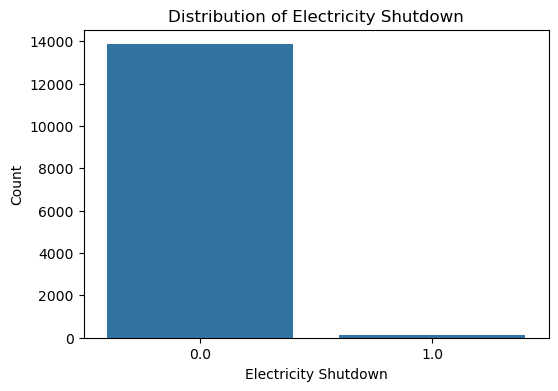

In [15]:
# Electricity shutdown distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='electricity_shutdown', data=train)
plt.title('Distribution of Electricity Shutdown')
plt.xlabel('Electricity Shutdown')
plt.ylabel('Count')
plt.show()

Coba smote jika hasil f1 scorenya rendah

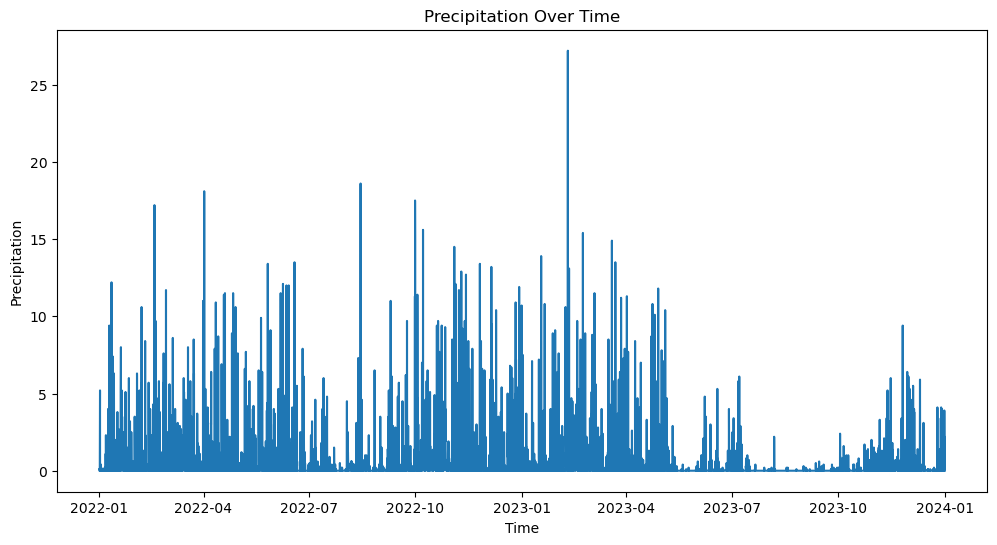

In [17]:
# Lineplot for precipitation
plt.figure(figsize=(12, 6))
sns.lineplot(x=train.index, y='precipitation', data=train)
plt.title('Precipitation Over Time')
plt.xlabel('Time')
plt.ylabel('Precipitation')
plt.show()

<Axes: xlabel='precipitation', ylabel='Density'>

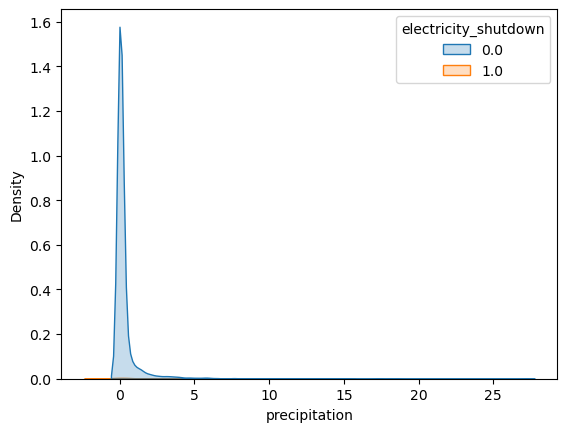

In [18]:
# KDE plot for precipitation by electricity shutdown
sns.kdeplot(data=train, x='precipitation', hue='electricity_shutdown', fill=True)

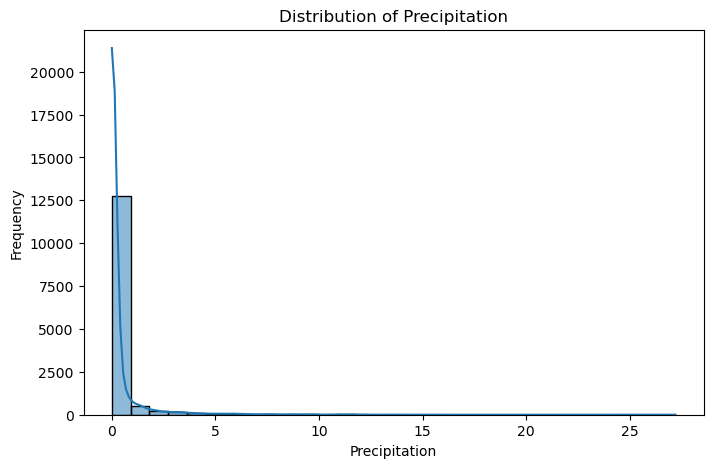

In [19]:
# Histogram for precipitation
plt.figure(figsize=(8, 5))
sns.histplot(train['precipitation'], bins=30, kde=True, fill=True)
plt.title('Distribution of Precipitation')
plt.xlabel('Precipitation')
plt.ylabel('Frequency')
plt.show()

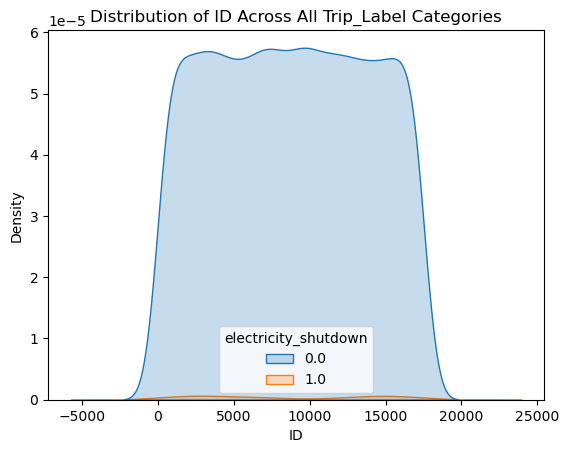

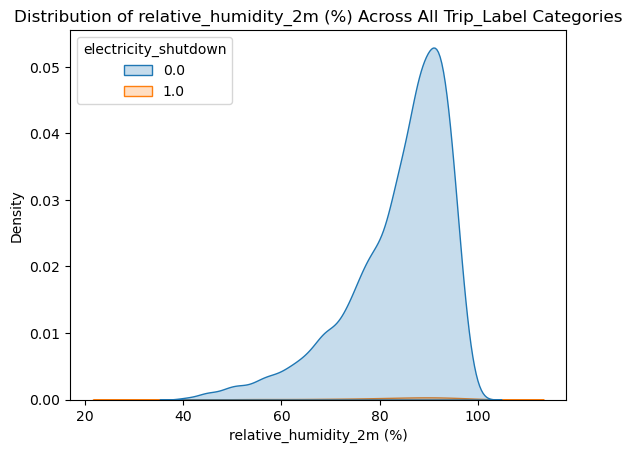

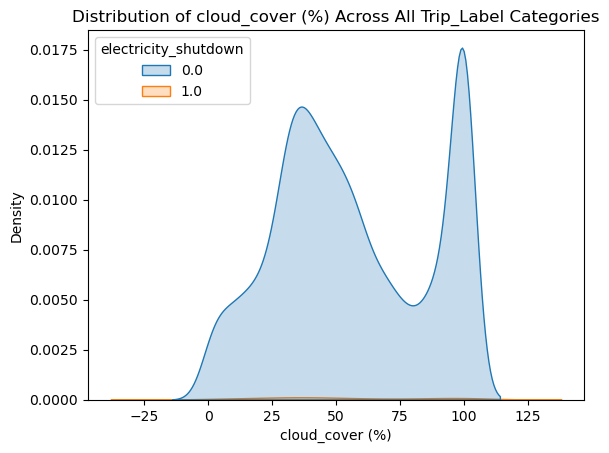

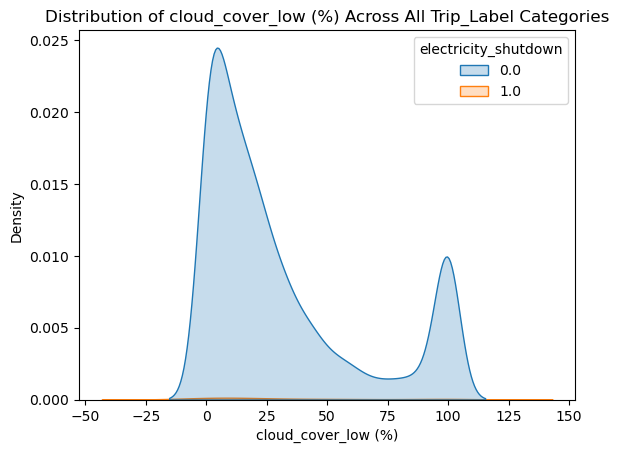

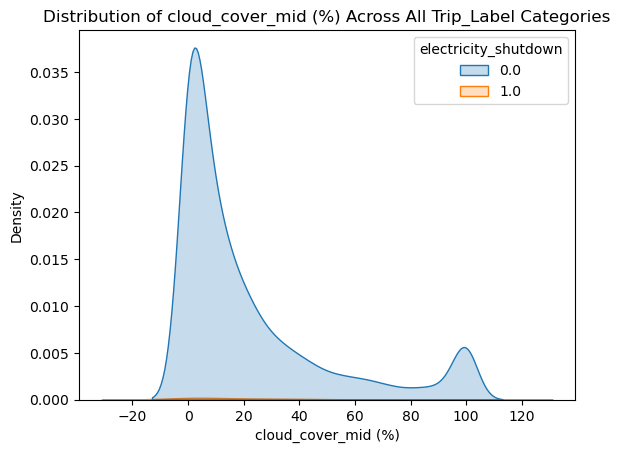

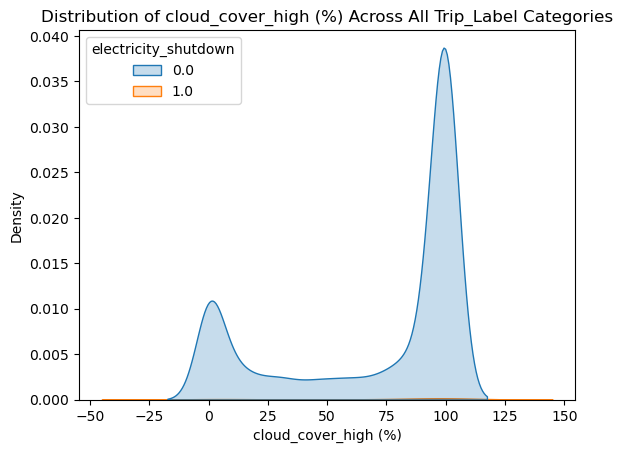

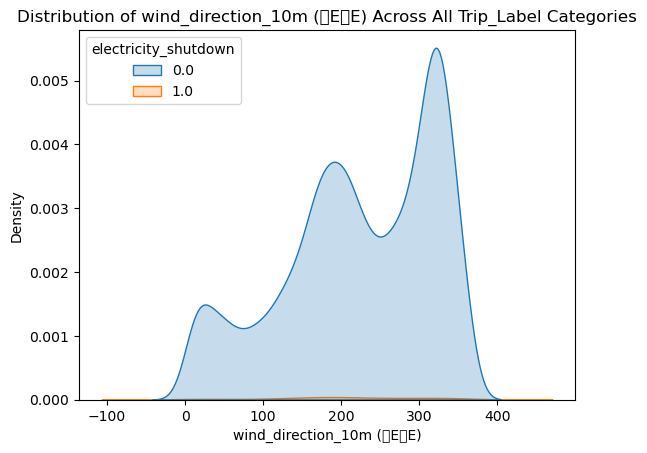

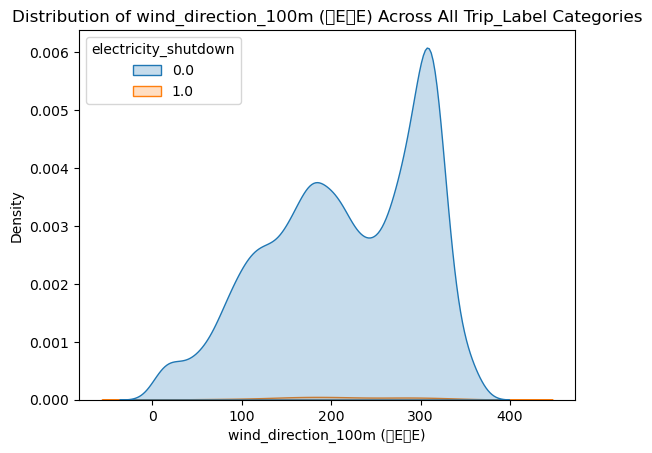

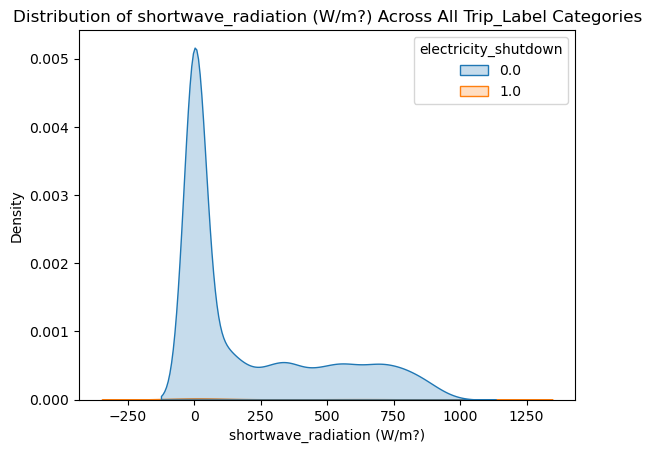

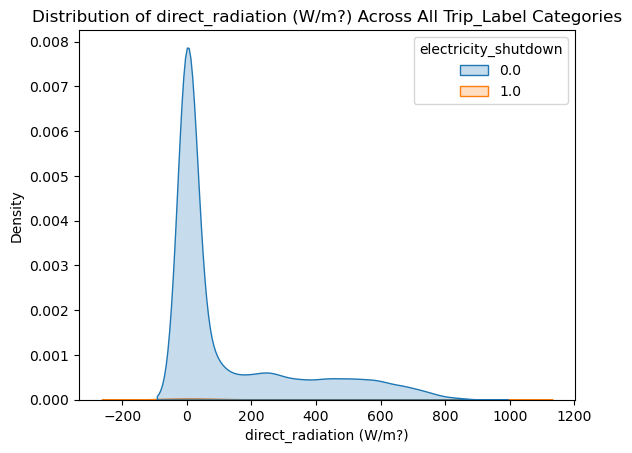

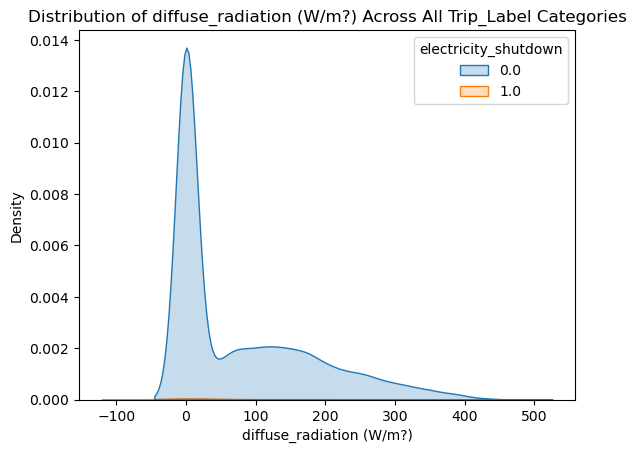

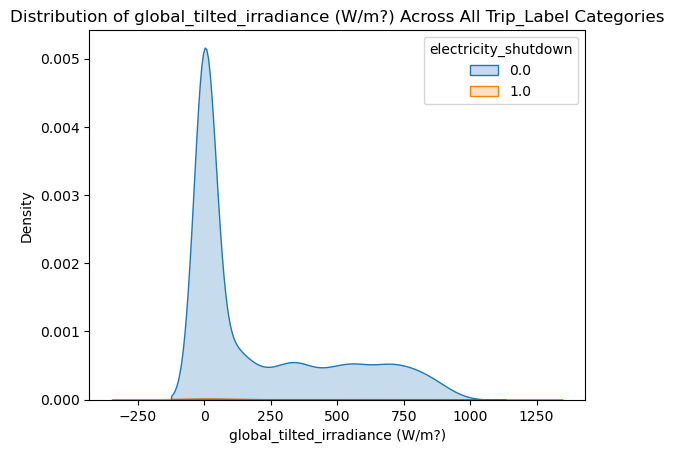

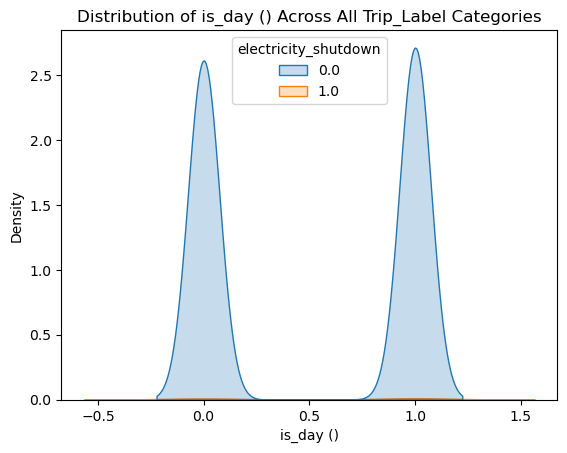

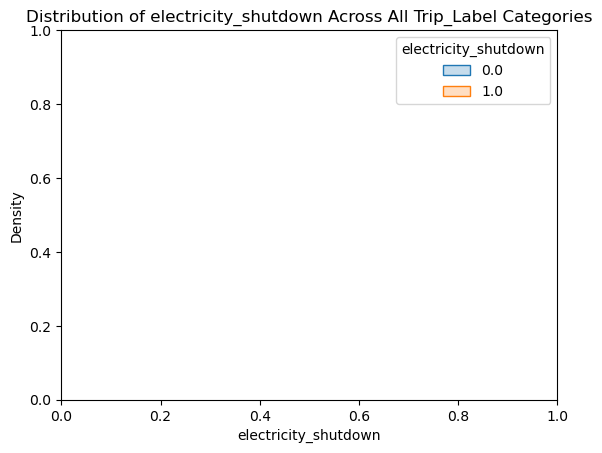

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
num_col = train.select_dtypes(include=[np.number]).columns.tolist()
for col in num_col:
  # isi hue pakai target untuk liat distribusi setiap kelas
  sns.kdeplot(data=train, x=col, hue='electricity_shutdown', fill=True)

  plt.title(f"Distribution of {col} Across All Trip_Label Categories")
  plt.show()

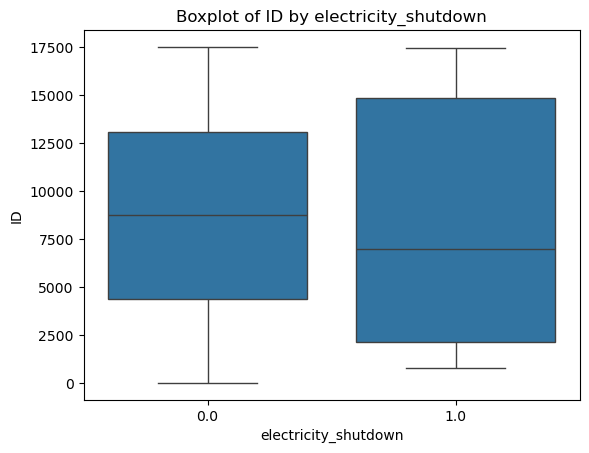

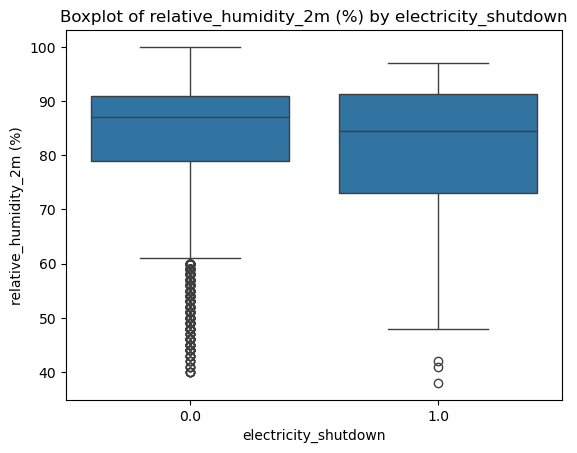

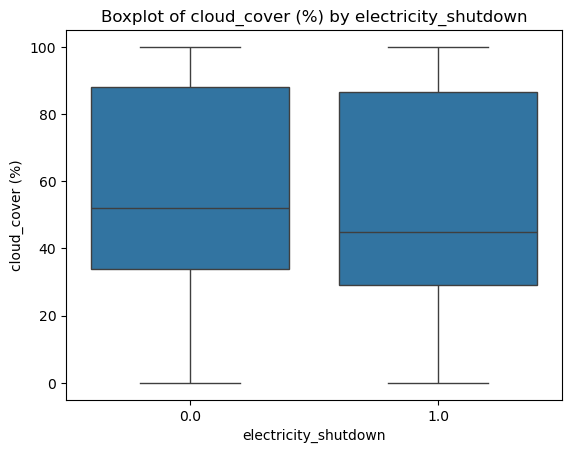

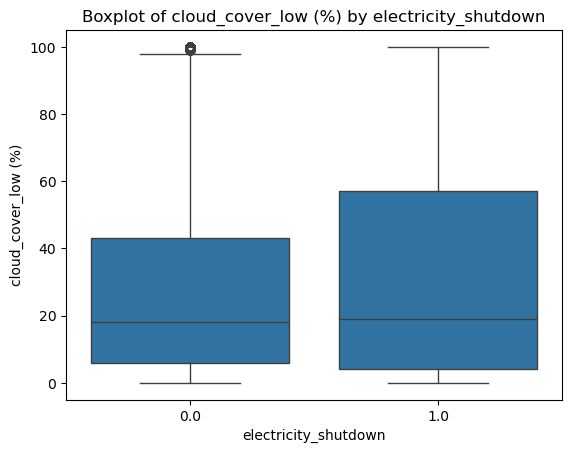

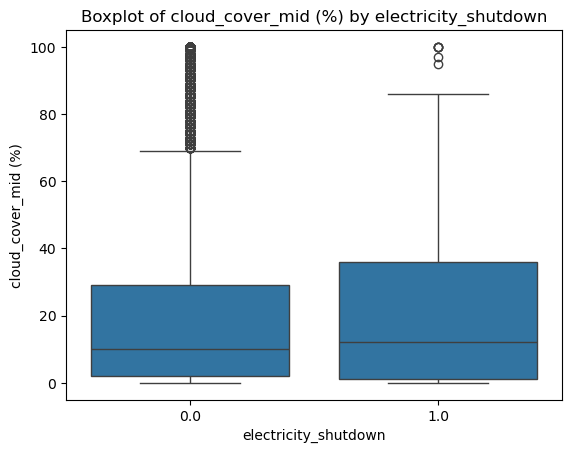

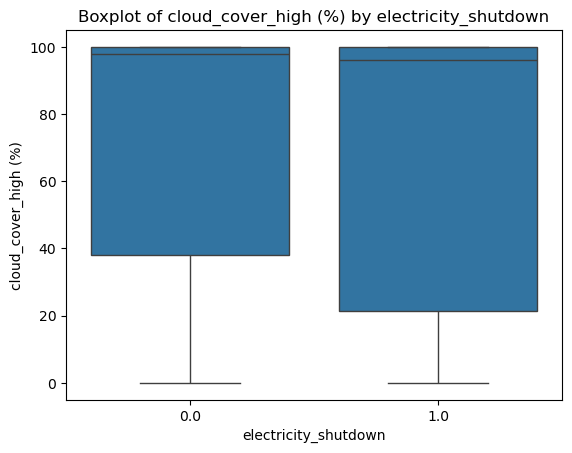

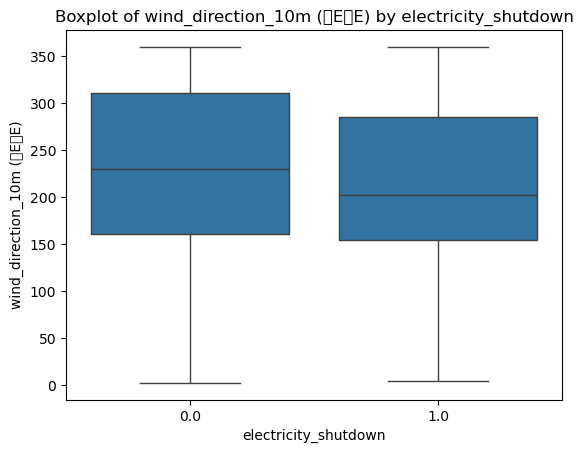

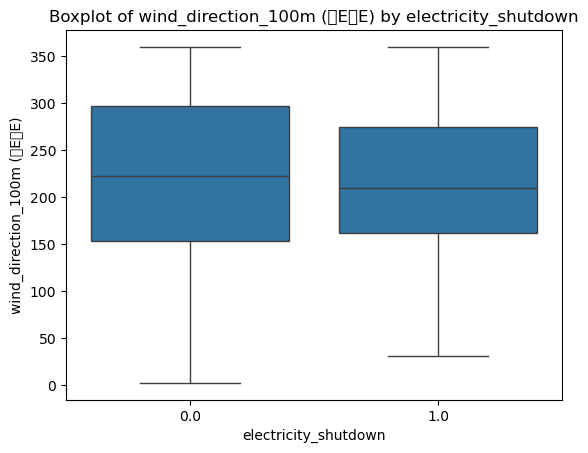

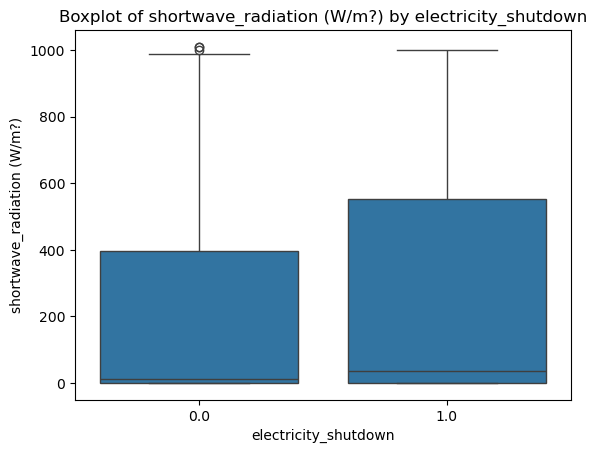

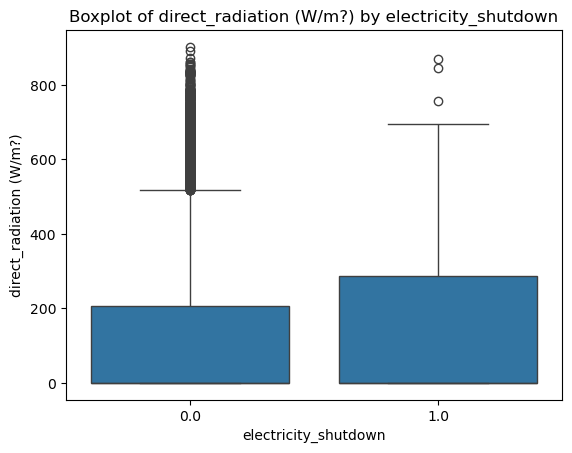

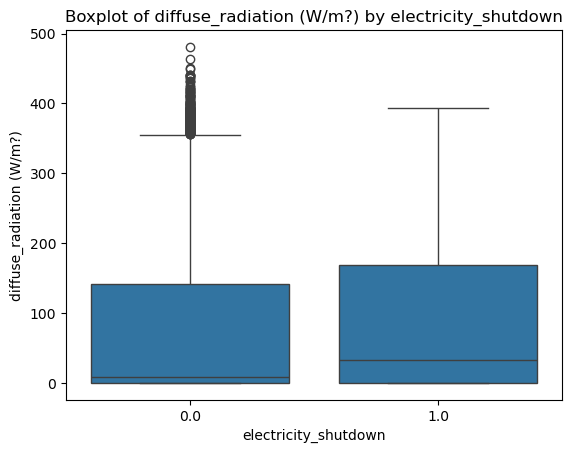

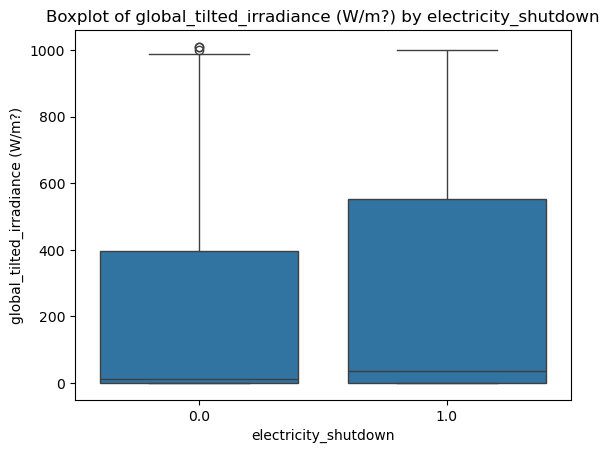

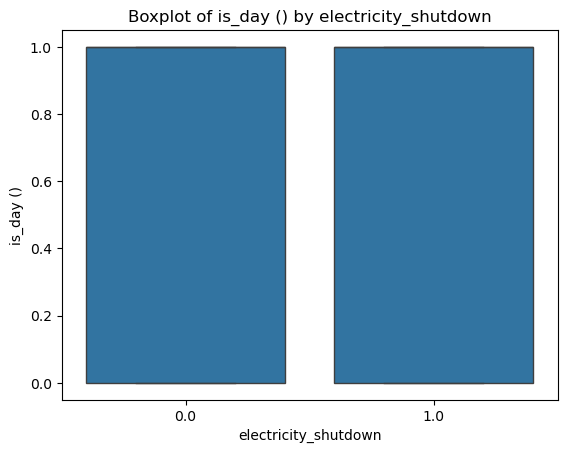

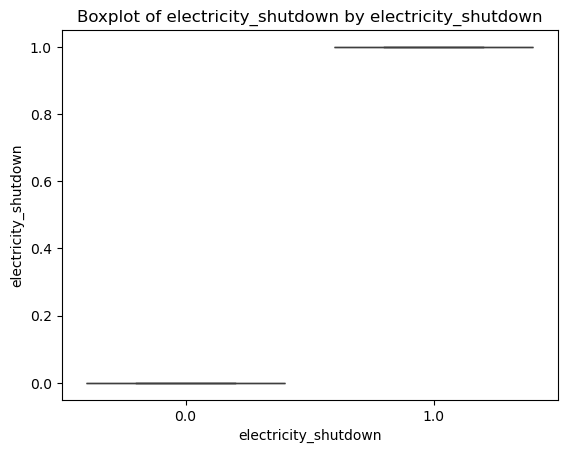

In [8]:
# Boxplot untuk melihat distribusi dan outlier
for col in num_col:
    sns.boxplot(x='electricity_shutdown', y=col, data=train)
    plt.title(f"Boxplot of {col} by electricity_shutdown")
    plt.show()

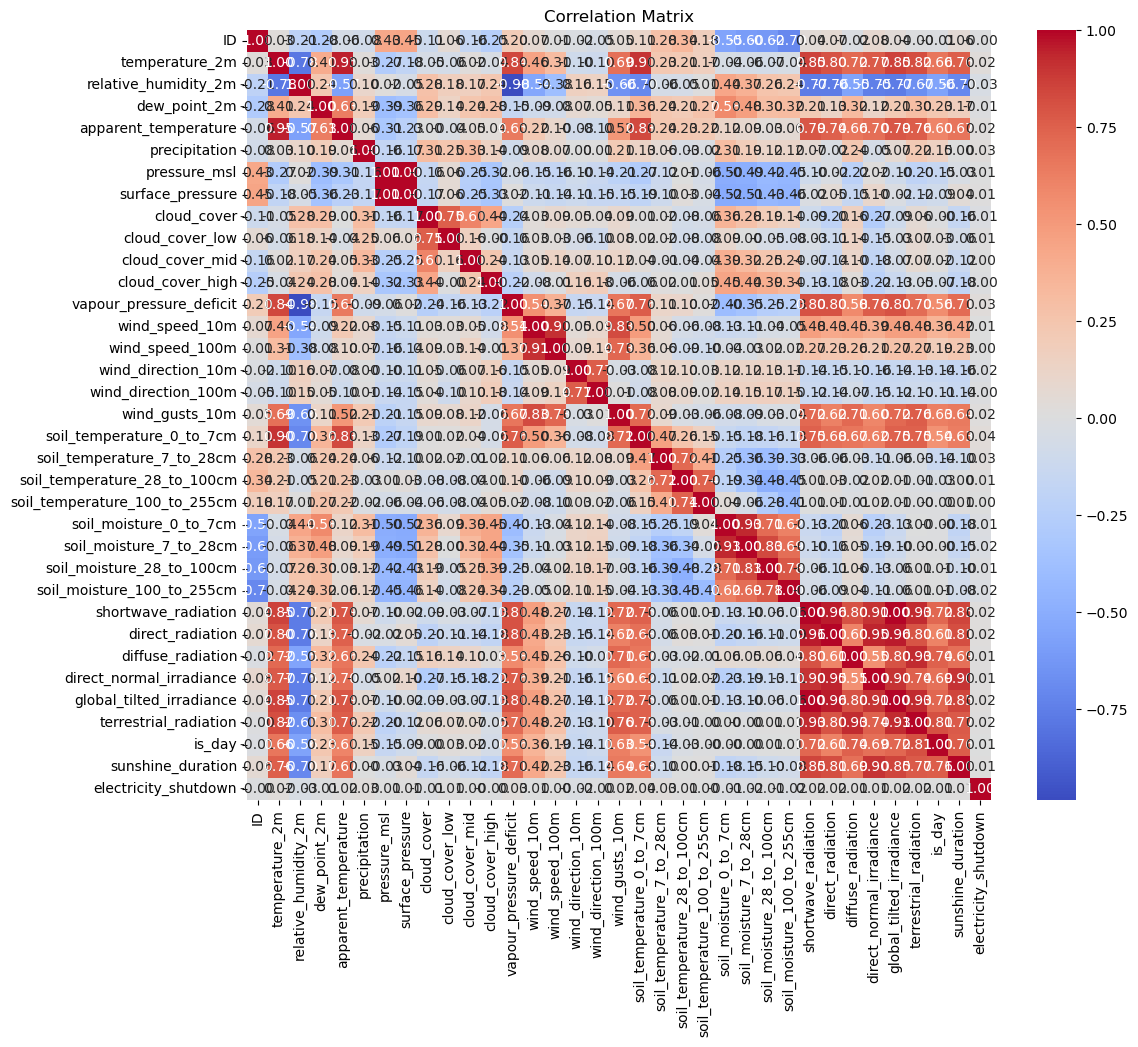

In [22]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [23]:
train.corr()['precipitation'].sort_values(ascending=False)

# Get above 0.01 correlation with target
correlation_threshold = 0.1
correlated_features = train.corr()['precipitation'].abs() > correlation_threshold
correlated_features = correlated_features[correlated_features].index.tolist()
print(f"Features with correlation above {correlation_threshold} with target:")
print(correlated_features)

Features with correlation above 0.1 with target:
['relative_humidity_2m', 'dew_point_2m', 'precipitation', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'wind_gusts_10m', 'soil_temperature_0_to_7cm', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm', 'soil_moisture_100_to_255cm', 'diffuse_radiation', 'terrestrial_radiation', 'is_day']


# Preprocessing

## Missing value handling

In [24]:
train.columns

Index(['ID', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
       'apparent_temperature', 'precipitation', 'pressure_msl',
       'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid',
       'cloud_cover_high', 'vapour_pressure_deficit', 'wind_speed_10m',
       'wind_speed_100m', 'wind_direction_10m', 'wind_direction_100m',
       'wind_gusts_10m', 'soil_temperature_0_to_7cm',
       'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm',
       'soil_temperature_100_to_255cm', 'soil_moisture_0_to_7cm',
       'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm',
       'soil_moisture_100_to_255cm', 'shortwave_radiation', 'direct_radiation',
       'diffuse_radiation', 'direct_normal_irradiance',
       'global_tilted_irradiance', 'terrestrial_radiation', 'is_day',
       'sunshine_duration', 'electricity_shutdown'],
      dtype='object')

In [25]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17520 entries, 2022-01-01 00:00:00 to 2023-12-31 23:00:00
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             17520 non-null  int64  
 1   temperature_2m                 9499 non-null   float64
 2   relative_humidity_2m           15761 non-null  float64
 3   dew_point_2m                   17520 non-null  float64
 4   apparent_temperature           17520 non-null  float64
 5   precipitation                  13978 non-null  float64
 6   pressure_msl                   17520 non-null  float64
 7   surface_pressure               15706 non-null  float64
 8   cloud_cover                    13169 non-null  float64
 9   cloud_cover_low                13979 non-null  float64
 10  cloud_cover_mid                14896 non-null  float64
 11  cloud_cover_high               17520 non-null  int64  
 12  vapour_pres

In [26]:
train.drop(columns=['ID'], inplace=True)
test.drop(columns=['ID'], inplace=True)

In [27]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler

knn = KNNImputer(n_neighbors=5)
mice = IterativeImputer(random_state=42)
standard = StandardScaler()
minmax = MinMaxScaler()

target_col = ['electricity_shutdown', 'precipitation']

# Impute missing values using KNNImputer
imputer = knn
train_imputed = pd.DataFrame(imputer.fit_transform(train.drop(columns=target_col)), columns=train.drop(columns=target_col).columns, index=train.index)
test_imputed = pd.DataFrame(imputer.transform(test), columns=test.columns, index=test.index)
train_imputed[target_col] = train[target_col]

# Impute missing values on electricity_shutdown using mode imputation
imputer_mode = SimpleImputer(strategy='most_frequent')
train_imputed['electricity_shutdown'] = imputer_mode.fit_transform(train_imputed[['electricity_shutdown']])

# Impute missing values on precipitation using linear regression imputation
imputer_lr = LinearRegression()
feature_lr = correlated_features.copy()
nonmissing_lr = train_imputed[feature_lr].dropna().drop(columns='precipitation')
imputer_lr.fit(nonmissing_lr, train_imputed.loc[nonmissing_lr.index, 'precipitation'])
filled_values = imputer_lr.predict(train_imputed[feature_lr].drop(columns='precipitation'))
train_imputed['precipitation'] = train_imputed['precipitation'].fillna(pd.Series(filled_values, index=train_imputed.index))


In [28]:
train_imputed.columns

Index(['temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
       'apparent_temperature', 'pressure_msl', 'surface_pressure',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'vapour_pressure_deficit', 'wind_speed_10m', 'wind_speed_100m',
       'wind_direction_10m', 'wind_direction_100m', 'wind_gusts_10m',
       'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm',
       'soil_temperature_28_to_100cm', 'soil_temperature_100_to_255cm',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'soil_moisture_100_to_255cm',
       'shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
       'direct_normal_irradiance', 'global_tilted_irradiance',
       'terrestrial_radiation', 'is_day', 'sunshine_duration',
       'electricity_shutdown', 'precipitation'],
      dtype='object')

# Machine Learning Approach Training

In [43]:
from sklearn.model_selection import train_test_split

X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(train_imputed.drop(columns=["electricity_shutdown"]), train_imputed['electricity_shutdown'], test_size=0.2, random_state=42, stratify=train_imputed['electricity_shutdown'])
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(train_imputed.drop(columns=target_col), train_imputed['precipitation'], test_size=0.2, random_state=42)

## Scaling

In [50]:
# Scale the features using MinMaxScaler
scaler = standard

X_train_clf = scaler.fit_transform(X_train_clf)
X_val_clf = scaler.transform(X_val_clf)

X_train_reg = scaler.fit_transform(X_train_reg)
X_val_reg = scaler.transform(X_val_reg)

## Regression Case

In [125]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, classification_report, root_mean_squared_error, f1_score

reg = RandomForestRegressor(random_state=42)

reg.fit(X_train_reg, y_train_reg)

y_pred_reg = reg.predict(X_val_reg)

rmse = root_mean_squared_error(y_val_reg, y_pred_reg)
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 0.6577405749641577


In [126]:
# # Coba ARIMA
# import pmdarima as pm

# auto_arima_model = pm.auto_arima(train_imputed['precipitation'], seasonal=True, m=12, trace=True)

# # Get rmse from auto_arima_model
# y_pred_arima = auto_arima_model.predict(n_periods=len(y_val_reg))
# rmse_arima = root_mean_squared_error(y_val_reg, y_pred_arima)
# print(f"Root Mean Squared Error from ARIMA: {rmse_arima}")

## Classification Case

## Resampling

In [51]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_clf, y_train_clf = smote.fit_resample(X_train_clf, y_train_clf)

In [53]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import AdaBoostClassifier

class_weight = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_clf), y=y_train_clf)

clf = XGBClassifier(random_state=42)
clf.fit(X_train_clf, y_train_clf)
y_pred_clf = clf.predict(X_val_clf)
print(classification_report(y_val_clf, y_pred_clf))
print(f1_score(y_val_clf, y_pred_clf, average='macro'))
f1 = f1_score(y_val_clf, y_pred_clf, average='macro')

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      3478
         1.0       0.27      0.12      0.16        26

    accuracy                           0.99      3504
   macro avg       0.63      0.56      0.58      3504
weighted avg       0.99      0.99      0.99      3504

0.5788575837349328


# Deep Learning Approach Training

Multivariate forecasting except the electricity_shutdown, and the forecast result of precipitation gonna be used as a feature to predict electricity_shutdown i guess?

1st plan i'm trynna do multitask learning on the attention module, i was planning to do the cross attention?? idk if it's work or not but i haven't figured out how to make it happen simultaneously for the clf and reg at the same time

2nd plan i'll do the regression first using transformer encoder layer, and the result (precipitation) gonna be used as a feature to classify

## Preprocessing

### Split for regression

In [32]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Take all for multivariate regression
X_train_dl_reg = train_imputed.drop(columns=['electricity_shutdown'])
y_train_dl_reg = train_imputed.drop(columns=['electricity_shutdown'])

# Use TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=5)

for train_index, val_index in tscv.split(X_train_dl_reg):
    X_train_fold, X_val_fold = X_train_dl_reg.iloc[train_index], X_train_dl_reg.iloc[val_index]
    y_train_fold, y_val_fold = y_train_dl_reg.iloc[train_index], y_train_dl_reg.iloc[val_index]

### Scaling

In [33]:
scaler = MinMaxScaler()

X_train_fold_scaled = scaler.fit_transform(X_train_fold)
X_val_fold_scaled = scaler.transform(X_val_fold)

# y discale juga soalnya nanti bakal recursive forecasting
y_train_fold_scaled = scaler.transform(y_train_fold)
y_val_fold_scaled = scaler.transform(y_val_fold)

### Time sequence

In [34]:
import torch
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs, dtype=torch.float32).to(device), torch.tensor(ys, dtype=torch.float32).to(device)

X_train_fold_seq, y_train_fold_seq = create_sequences(X_train_fold_scaled, seq_length=12) # Ambil 12 jam terakhir untuk prediksi 1 jam ke depan
X_val_fold_seq, y_val_fold_seq = create_sequences(X_val_fold_scaled, seq_length=12) # Ambil 12 jam terakhir untuk prediksi 1 jam ke depan

In [35]:
X_train_fold_seq.shape

torch.Size([14588, 12, 33])

## Regression

### Attention module

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class AdditiveAttention(nn.Module):
    def __init__(self, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.LazyLinear(num_hiddens, bias=False)
        self.W_q = nn.LazyLinear(num_hiddens, bias=False)
        self.w_v = nn.LazyLinear(1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        
        # Expand dimensi untuk broadcasting:
        # queries: (batch, n_q, 1, hidden)
        # keys: (batch, 1, n_k, hidden)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        
        # scores: (batch, n_q, n_k)
        scores = self.w_v(features).squeeze(-1)
        
        # Mendapatkan bobot atensi (softmax)
        self.attention_weights = masked_softmax(scores, valid_lens)
        
        # Proses Weighted Sum:
        # 1. dropout pada bobot
        attn_probs = self.dropout(self.attention_weights) 
        
        # 2. Perkalian matriks antara bobot dan values
        # (batch, n_q, n_k) @ (batch, n_k, value_dim) -> (batch, n_q, value_dim)
        context_vector = torch.bmm(attn_probs, values)
        
        return context_vector

class GRUWithAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, output_dim_reg, output_dim_clf):
        super(GRUWithAttention, self).__init__()
        
        self.gru_encoder = nn.GRU(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers,
            batch_first=True, 
            dropout=dropout if num_layers > 1 else 0, 
            bidirectional=True
        )
        
        # Hidden dim dikali 2 karena bidirectional
        self.attention = AdditiveAttention(num_hiddens=hidden_dim * 2, dropout=dropout)
        
        self.decoder_reg = nn.Linear(hidden_dim * 2, output_dim_reg)
        self.decoder_clf = nn.Linear(hidden_dim * 2, output_dim_clf)
        
    def forward(self, x, valid_lens):
        # gru_out shape: (batch_size, seq_len, hidden_dim * 2)
        gru_out, _ = self.gru_encoder(x)
        
        # Kita gunakan gru_out sebagai Query, Key, dan Value (Self-Attention)
        # context: (batch, seq_len, hidden_dim * 2)
        context = self.attention(gru_out, gru_out, gru_out, valid_lens)
        
        # Weighted sum untuk seluruh sequence (meringkas informasi waktu)
        # Mengambil rata-rata atau token terakhir dari context vector
        final_representation = torch.mean(context, dim=1) 
        
        out_reg = self.decoder_reg(final_representation)
        out_clf = self.decoder_clf(final_representation)
                
        return out_reg, out_clf, self.attention.attention_weights
    
class MLPAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout, output_dim_reg, output_dim_clf):
        super(MLPAttention, self).__init__()
        
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.BatchNorm1d(hidden_dim)
        )

        self.attention = AdditiveAttention(num_hiddens=hidden_dim, dropout=dropout)

        self.decoder_reg = nn.Linear(hidden_dim, output_dim_reg)
        self.decoder_clf = nn.Linear(hidden_dim, output_dim_clf)

    def forward(self, x, valid_lens):
        mlp_out = self.mlp(x)
        context = self.attention(mlp_out, mlp_out, mlp_out, valid_lens)
        final_representation = torch.mean(context, dim=1)
        out_reg = self.decoder_reg(final_representation)
        out_clf = self.decoder_clf(final_representation)
        return out_reg, out_clf, self.attention.attention_weights

i'll try to do multitask learning (ugh it's hard tho)

In [ ]:
seq_length = X_train_fold_seq.shape[1]

y_train_clf_fold = train_imputed.loc[X_train_fold.index, 'electricity_shutdown'].to_numpy()
y_val_clf_fold = train_imputed.loc[X_val_fold.index, 'electricity_shutdown'].to_numpy()

y_train_clf_seq = torch.tensor(y_train_clf_fold[seq_length:], dtype=torch.float32, device=device)
y_val_clf_seq = torch.tensor(y_val_clf_fold[seq_length:], dtype=torch.float32, device=device)

train_ds = torch.utils.data.TensorDataset(
    X_train_fold_seq.float(),
    y_train_fold_seq.float(),
    y_train_clf_seq
)

val_ds = torch.utils.data.TensorDataset(
    X_val_fold_seq.float(),
    y_val_fold_seq.float(),
    y_val_clf_seq
)
val_ds = torch.utils.data.TensorDataset(torch.tensor(X_val_fold_seq, dtype=torch.float32), torch.tensor(y_val_fold_seq.values, dtype=torch.float32), torch.tensor(y_val_clf.values, dtype=torch.long))
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=32)

# To device
train_dl = [(x.to(device), y_reg.to(device), y_clf.to(device)) for x, y_reg, y_clf in train_dl]
val_dl = [(x.to(device), y_reg.to(device), y_clf.to(device)) for x, y_reg, y_clf in val_dl]

model = MLPAttention(input_dim=X_train_reg.shape[1], hidden_dim=64, dropout=0.5, output_dim_reg=1, output_dim_clf=1).to(device)
criterion_reg = nn.MSELoss()
criterion_clf = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    total_loss_reg = 0
    total_loss_clf = 0
    
    for x_batch, y_reg_batch, y_clf_batch in train_dl:
        optimizer.zero_grad()
        out_reg, out_clf, _ = model(x_batch, valid_lens=None)
        loss_reg = criterion_reg(out_reg.squeeze(), y_reg_batch)
        loss_clf = criterion_clf(out_clf.squeeze(), y_clf_batch.float())
        loss = loss_reg + loss_clf
        loss.backward()
        optimizer.step()
        
        total_loss_reg += loss_reg.item()
        total_loss_clf += loss_clf.item()
    
    avg_loss_reg = total_loss_reg / len(train_dl)
    avg_loss_clf = total_loss_clf / len(train_dl)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss Reg: {avg_loss_reg:.4f}, Loss Clf: {avg_loss_clf:.4f}")

TypeError: must be real number, not builtin_function_or_method

In [95]:
# def create_sequences(features, targets, seq_length):
#     xs = []
#     ys = []
    
#     # Konversi ke numpy jika masih berupa DataFrame/Series
#     if hasattr(features, 'values'): features = features.values
#     if hasattr(targets, 'values'): targets = targets.values
    
#     for i in range(len(features) - seq_length):
#         x = features[i:(i + seq_length)]
#         y = targets[i + seq_length]
#         xs.append(x)
#         ys.append(y)
    
#     return torch.tensor(xs, dtype=torch.float32).to(devicemps), \
#            torch.tensor(ys, dtype=torch.float32).to(devicemps)

# # Hyperparameters
# input_dim = len(train_imputed.columns) - 2  # Exclude target columns
# hidden_dim = 64
# num_layers = 2
# dropout = 0.2
# output_dim_reg = 1  # For regression (precipitation)
# output_dim_clf = 1  # For classification (electricity_shutdown)

# from torch.utils.data import DataLoader, TensorDataset

# # Make sequences for training
# seq_length = 7  # 7 days time step

# # Asumsi: kolom terakhir adalah target regresi, dan satu sebelum terakhir adalah klasifikasi
# # Sesuaikan 'target_col_name' dengan nama kolom asli Anda
# target_reg_col = 'precipitation'
# target_clf_col = 'electricity_shutdown'

# # Hapus .values jika variabel di bawah ini sudah hasil dari proses pre-processing (Scikit-Learn)
# X_train_seq, y_train_reg_seq = create_sequences(X_train_reg, y_train_reg, seq_length)
# _, y_train_clf_seq = create_sequences(X_train_reg, y_train_clf, seq_length)

# X_val_seq, y_val_reg_seq = create_sequences(X_val_reg, y_val_reg, seq_length)
# _, y_val_clf_seq = create_sequences(X_val_reg, y_val_clf, seq_length)

# # Buat DataLoader
# train_dataset = TensorDataset(X_train_seq, y_train_reg_seq, y_train_clf_seq)
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)

# val_dataset = TensorDataset(X_val_seq, y_val_reg_seq, y_val_clf_seq)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# # Initialize model, loss functions, and optimizer
# model = GRUWithAttention(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout, output_dim_reg=output_dim_reg, output_dim_clf=output_dim_clf).to(devicemps)
# criterion_reg = nn.MSELoss()
# criterion_clf = nn.BCEWithLogitsLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# num_epochs = 100
# model.to(devicemps)

# for epoch in range(num_epochs):
#     model.train()
#     total_loss = 0
    
#     for batch_X, batch_y_reg, batch_y_clf in train_loader:
#         optimizer.zero_grad()

#         # Forward pass
#         out_reg, out_clf, _ = model(batch_X, valid_lens=None)

#         # Regression Loss (MSE)
#         loss_reg = criterion_reg(out_reg.view(-1), batch_y_reg.view(-1))
        
#         # Classification Loss (BCE)
#         loss_clf = criterion_clf(out_clf.view(-1), batch_y_clf.view(-1).float())
    
#         # Gabungkan loss
#         loss = loss_reg + loss_clf
        
#         # Backward & Update per batch
#         loss.backward()
#         optimizer.step()
        
#         total_loss += loss.item()
    
#     # Validasi sederhana
#     model.eval()
#     with torch.no_grad():
#         val_loss = 0
#         for v_X, v_y_reg, v_y_clf in val_loader:
#             v_reg, v_clf, _ = model(v_X, valid_lens=None)
#             val_loss += (criterion_reg(v_reg.view(-1), v_y_reg.view(-1)) + 
#                         criterion_clf(v_clf.view(-1), v_y_clf.view(-1).float())).item()
    
#     print(f"Epoch {epoch+1:02d} | Train Loss: {total_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

Epoch 01 | Train Loss: 1.4041 | Val Loss: 1.4588
Epoch 02 | Train Loss: 1.3824 | Val Loss: 1.4550
Epoch 03 | Train Loss: 1.3794 | Val Loss: 1.4558
Epoch 04 | Train Loss: 1.3777 | Val Loss: 1.4559
Epoch 05 | Train Loss: 1.3792 | Val Loss: 1.4713
Epoch 06 | Train Loss: 1.3774 | Val Loss: 1.4560
Epoch 07 | Train Loss: 1.3774 | Val Loss: 1.4623
Epoch 08 | Train Loss: 1.3772 | Val Loss: 1.4558
Epoch 09 | Train Loss: 1.3760 | Val Loss: 1.4549
Epoch 10 | Train Loss: 1.3802 | Val Loss: 1.4592
Epoch 11 | Train Loss: 1.3749 | Val Loss: 1.4591
Epoch 12 | Train Loss: 1.3751 | Val Loss: 1.4552
Epoch 13 | Train Loss: 1.3748 | Val Loss: 1.4602
Epoch 14 | Train Loss: 1.3755 | Val Loss: 1.4636
Epoch 15 | Train Loss: 1.3549 | Val Loss: 1.4623
Epoch 16 | Train Loss: 1.3728 | Val Loss: 1.4570
Epoch 17 | Train Loss: 1.3675 | Val Loss: 1.4636
Epoch 18 | Train Loss: 1.3717 | Val Loss: 1.4629
Epoch 19 | Train Loss: 1.3684 | Val Loss: 1.4625
Epoch 20 | Train Loss: 1.3692 | Val Loss: 1.4594
Epoch 21 | Train Los

In [129]:
# Get RMSE and F1 Score from the model predictions on validation set
model.eval()
with torch.no_grad():
    val_reg_preds = []
    val_clf_preds = []
    val_reg_targets = []
    val_clf_targets = []
    
    for v_X, v_y_reg, v_y_clf in val_loader:
        v_reg, v_clf, _ = model(v_X, valid_lens=None)
        
        val_reg_preds.extend(v_reg.cpu().numpy())
        val_clf_preds.extend(torch.sigmoid(v_clf).cpu().numpy())  # Apply sigmoid for probabilities
        val_reg_targets.extend(v_y_reg.cpu().numpy())
        val_clf_targets.extend(v_y_clf.cpu().numpy())
    
    # Convert lists to numpy arrays
    val_reg_preds = np.array(val_reg_preds).flatten()
    val_clf_preds = np.array(val_clf_preds).flatten()
    val_reg_targets = np.array(val_reg_targets).flatten()
    val_clf_targets = np.array(val_clf_targets).flatten()
    
    # Calculate RMSE for regression
    rmse = root_mean_squared_error(val_reg_targets, val_reg_preds)
    
    # Calculate F1 Score for classification (thresholding at 0.5)
    clf_pred_labels = (val_clf_preds >= 0.5).astype(int)
    f1 = f1_score(val_clf_targets, clf_pred_labels, average='macro')

print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation F1 Score: {f1:.4f}")
final_score = calculate_final_score(rmse, f1)
print(f"Final Score: {final_score:.4f}")

Validation RMSE: 1.2967
Validation F1 Score: 0.4979
Final Score: 0.6510


### Transformer Module

In [36]:
import math
from torch import nn, Tensor
from torch.nn.modules.transformer import TransformerEncoderLayer
import torch.nn.functional as F

#d_model itu embbeding size
#dim_feedforward itu hidden size di feedforward network dalam transformer encoder layer

# Positional Encoding biar model transformernya bisa nangkep informasi posisi waktu dalam sequence data
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000): # max_len itu panjang maksimal sequence yang bisa diproses, misak 12 karena kita cuma ambil 12 jam terakhir
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # pe = pe.unsqueeze(0).transpose(0, 1)

        pe = pe.unsqueeze(0) # Shape: (1, 5000, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # Memotong PE sesuai panjang sekuens x yang masuk (Dimensi 1 adalah seq_len) dan menambahkan ke input embedding x
        x = x + self.pe[:, :x.size(1), :]
        # x = x + self.pe[:x.size(0), :]
        return self.dropout(x)
    
class RegressionTransformer(nn.Module):
    def __init__(self, input_dim, d_model, nhead, dim_feedforward, dropout, seq_len, device):
        super(RegressionTransformer, self).__init__()

        self.input_projection = nn.Linear(input_dim, d_model) # input embedding layer untuk proyeksi fitur ke dimensi d_model
        self.positional_encoding = PositionalEncoding(d_model, dropout, max_len=seq_len) # Positional encoding
        self.encoder_layer = TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True) # Transformer encoder layer
        # self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers) # Sebenernya opsional mau brp encoder layer, bisa 1 aja buat eksperimen awal
        self.regressor = nn.Linear(dim_feedforward // 16, y_train_dl_reg.shape[1])  # Output untuk regresi multivariat (jumlah target variabel)

        # Sebelum masuk linear, output transformer encoder biasanya masih dalam bentuk (batch_size, seq_len, d_model),
        # diflatten ke (batch_size, seq_len * d_model) atau bisa juga diambil token terakhir atau rata-rata pooling untuk mendapatkan representasi global dari sequence, 
        # baru masuk linear layer
        # Linear layer before regressor untuk mengurangi dimensi dari d_model ke hidden_dim (misal 64) biar gak terlalu overfitting
        # Regression Component
        self.linear1 = nn.Linear(seq_len*d_model, int(dim_feedforward))
        self.linear2 = nn.Linear(int(dim_feedforward), int(dim_feedforward/2))
        self.linear3 = nn.Linear(int(dim_feedforward/2), int(dim_feedforward/4))
        self.linear4 = nn.Linear(int(dim_feedforward/4), int(dim_feedforward/8))
        self.linear5 = nn.Linear(int(dim_feedforward/8), int(dim_feedforward/16))

        self.d_model = d_model
        self.device = device
        self.seq_len = seq_len
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src):
        src_mask = self._generate_square_subsequent_mask()
        src_mask.to(self.device)
        src = self.input_projection(src)  # Proyeksi input ke d_model
        src = self.positional_encoding(src)  # Tambahkan positional encoding
        transformer_out = self.encoder_layer(src, src_mask=src_mask) # Output shape: (batch_size, seq_len, d_model) dari transformer encoder
        out = transformer_out.reshape((-1, self.seq_len*self.d_model)) # Flatten output transformer encoder

        out = self.linear1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.linear2(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.linear3(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.linear4(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.linear5(out)
        out = self.relu(out)
        out = self.dropout(out)

        return self.regressor(out)
    
    # Function Copied from PyTorch Library to create upper-triangular source mask
    # Masking biar model gak bisa "melihat" ke masa depan (future time steps) saat memproses sequence data,
    # karena kita cuma boleh pakai informasi dari waktu sebelumnya untuk prediksi waktu berikutnya
    def _generate_square_subsequent_mask(self):
        return torch.triu(
            torch.full((self.seq_len, self.seq_len), float('-inf'), dtype=torch.float32, device=self.device),
            diagonal=1,
        )
    
# Coba tanpa linear layer tambahan, langsung dari output transformer encoder ke regressor
class RegressionTransformer2(nn.Module):
    def __init__(self, input_dim, d_model, nhead, dim_feedforward, dropout, seq_len, device):
        super(RegressionTransformer2, self).__init__()

        self.input_embedding = nn.Linear(input_dim, d_model) # input embedding layer untuk proyeksi fitur ke dimensi d_model
        self.positional_encoding = PositionalEncoding(d_model, dropout, max_len=seq_len) # Positional encoding
        self.encoder_layer = TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True) # Transformer encoder layer
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=2) # Stack 2 encoder layer untuk model yang lebih dalam
        self.regressor = nn.Linear(d_model, y_train_dl_reg.shape[1])

        self.device = device
        self.seq_len = seq_len

    def forward(self, src):
        src_mask = self._generate_square_subsequent_mask().to(self.device)
        src = self.input_embedding(src)  # Proyeksi input ke d_model
        src = self.positional_encoding(src)  # Tambahkan positional encoding
        transformer_out = self.transformer_encoder(src, mask=src_mask) # Output shape: (batch_size, seq_len, d_model)
        out = transformer_out[:, -1, :]  # Ambil token terakhir sebagai representasi global dari sequence, bisa coba GAP, flatten, atau token terakhir
        return self.regressor(out)
    
    def _generate_square_subsequent_mask(self):
        return torch.triu(
            torch.full((self.seq_len, self.seq_len), float('-inf'), dtype=torch.float32, device=self.device),
            diagonal=1,
        )

In [40]:
train_ds = torch.utils.data.TensorDataset(torch.tensor(X_train_fold_seq, dtype=torch.float32), torch.tensor(y_train_fold_seq, dtype=torch.float32))
val_ds = torch.utils.data.TensorDataset(torch.tensor(X_val_fold_seq, dtype=torch.float32), torch.tensor(y_val_fold_seq, dtype=torch.float32))
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=False)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=32)

model = RegressionTransformer(input_dim=X_train_fold_seq.shape[2], d_model=64, nhead=4, dim_feedforward=2048, dropout=0.0, seq_len=X_train_fold_seq.shape[1], device=device).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # bisa coba adamW atau optimizers lain yang lebih cocok untuk transformer

num_epochs = 50
train_loss = []
val_loss_list = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for x_batch, y_batch in train_dl:
        optimizer.zero_grad()
        out = model(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_dl)
    train_loss.append(avg_loss)
    
    # Validasi sederhana
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for v_X, v_y in val_dl:
            v_out = model(v_X)
            val_loss += criterion(v_out, v_y).item()
            
    
    val_loss_list.append(val_loss / len(val_dl))
    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss_list[-1]:.4f}")

Epoch 01 | Train Loss: 0.0345 | Val Loss: 0.0921
Epoch 02 | Train Loss: 0.0240 | Val Loss: 0.0978
Epoch 03 | Train Loss: 0.0231 | Val Loss: 0.0928
Epoch 04 | Train Loss: 0.0224 | Val Loss: 0.0933
Epoch 05 | Train Loss: 0.0222 | Val Loss: 0.0871
Epoch 06 | Train Loss: 0.0225 | Val Loss: 0.0859
Epoch 07 | Train Loss: 0.0221 | Val Loss: 0.0920
Epoch 08 | Train Loss: 0.0215 | Val Loss: 0.0887
Epoch 09 | Train Loss: 0.0211 | Val Loss: 0.0856
Epoch 10 | Train Loss: 0.0211 | Val Loss: 0.0959
Epoch 11 | Train Loss: 0.0208 | Val Loss: 0.0897
Epoch 12 | Train Loss: 0.0210 | Val Loss: 0.0851
Epoch 13 | Train Loss: 0.0211 | Val Loss: 0.0987
Epoch 14 | Train Loss: 0.0208 | Val Loss: 0.0894
Epoch 15 | Train Loss: 0.0205 | Val Loss: 0.0796
Epoch 16 | Train Loss: 0.0202 | Val Loss: 0.0812
Epoch 17 | Train Loss: 0.0198 | Val Loss: 0.0853
Epoch 18 | Train Loss: 0.0197 | Val Loss: 0.0868
Epoch 19 | Train Loss: 0.0197 | Val Loss: 0.0846
Epoch 20 | Train Loss: 0.0193 | Val Loss: 0.0859
Epoch 21 | Train Los

In [42]:
# TensorDataset has no .shape — use len() for number of samples or inspect underlying tensors
print("num_samples:", len(train_ds))
print("first tensor shape:", train_ds.tensors[0].shape)
# If you want batch shape from a DataLoader:
batch = next(iter(train_dl))
print("batch shapes:", [b.shape for b in batch])

num_samples: 14588
first tensor shape: torch.Size([14588, 12, 33])
batch shapes: [torch.Size([32, 12, 33]), torch.Size([32, 33])]


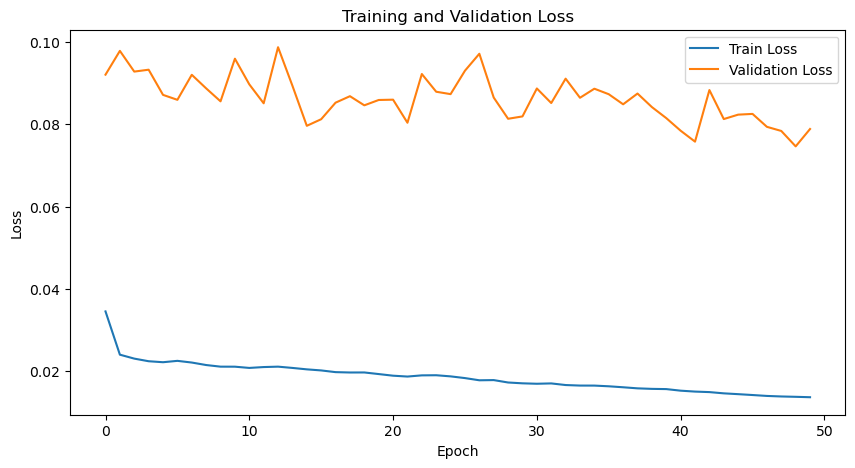

In [41]:
# plot train and val loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epoch') 
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [55]:
from sklearn.metrics import root_mean_squared_error

# Get RMSE from the model predictions on validation set
model.eval()
with torch.no_grad():
    val_preds = []
    val_targets = []
    
    for v_X, v_y in val_dl:
        v_out = model(v_X)
        val_preds.extend(v_out.cpu().numpy())
        val_targets.extend(v_y.cpu().numpy())
    
    val_preds = np.array(val_preds).flatten()
    val_targets = np.array(val_targets).flatten()
    
    rmse = root_mean_squared_error(val_targets, val_preds)
    print(f"Validation RMSE: {rmse:.4f}")


Validation RMSE: 0.2807


overfit damn it

# Final Scores

i'm using the regression from the transformer models and the classification using XGBClf

final score on validation sample

In [57]:
# Calculate final score by RMSE x (1 - F1 Score)
def calculate_final_score(rmse, f1):
    return rmse * (1 - f1)

final_score = calculate_final_score(rmse, f1_score(y_val_clf, y_pred_clf, average='macro'))
print(f"Final Score: {final_score}")

Final Score: 0.11820765944108867


# Predict

In [ ]:
!kaggle competitions submit -c sebelas-maret-statistics-data-science-2024 -f submission.csv  -m "Message"

can't submit, the comps already deleted :/